This is my attempt of applying edge detection techniques without major cv library functionsi

To grey scale, we take the R channel of the image

(1477, 1108, 3)
[99 70 30]
(1477, 1108)
99.0


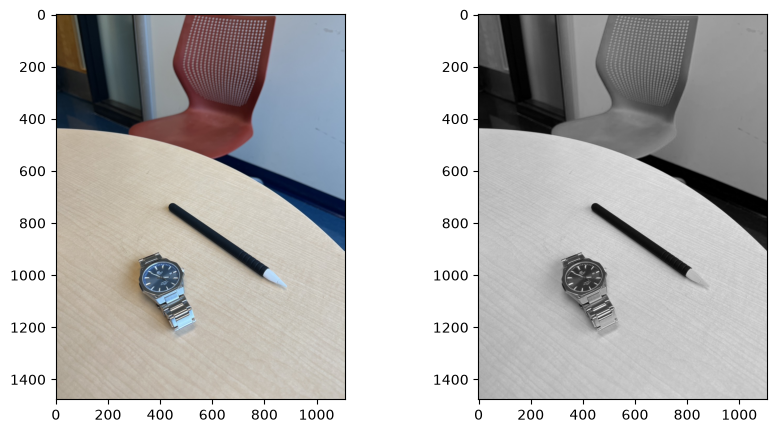

In [41]:
import pandas as pd
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import math

img = mpimg.imread('img.jpg')
print(img.shape)
print(img[0][0]) # [R G B]
# to grey scale 
grey_img = np.dot(img[..., :3], [1, 0, 0]).astype(np.float32)
print(grey_img.shape)
print(grey_img[0][0])
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(img)
axes[1].imshow(grey_img, cmap='gray')

Before processing the image, we need to smooth them
### Gaussian Smoothing
$$
I_{smooth} = G(x, y, \sigma) \ast I(x, y)
$$
where $G(x, y, \sigma) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$ is the 2D Gaussian distribution

We will use a 3x3 kernel/sliding window

$$
\begin{bmatrix}
(-1, -1) & (0, -1) & (1, -1)\\
(-1,  0) & (0,  0) & (1,  0)\\
( 1, -1) & (0,  1) & (1,  1)\\
\end{bmatrix}
$$

[Taichi] Starting on arch=x64


Text(0.5, 1.0, 'With smoothing')

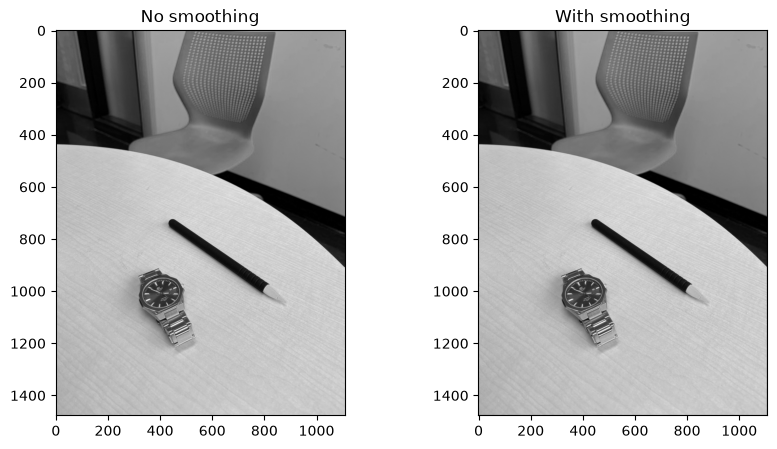

In [42]:
import taichi as ti
ti.init(arch=ti.cpu)
smoothed_img = np.zeros_like(grey_img, dtype=np.float32)
@ti.func
def GD(x, y, sigma):
    ''' Gaussian Distribution given x, y, sigma
    '''
    return (1/(2 * math.pi * sigma * sigma)) * ti.exp(-(x * x + y * y)/(2 * sigma * sigma))

@ti.kernel
def GaussianSmoothing(img: ti.types.ndarray(),
                      out: ti.types.ndarray(),
                      sigma: ti.types.float32):
    height = img.shape[0]
    width = img.shape[1]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            weight_sum = 0
            # 3x3 kernel around pixel i, j
            for u in range(-1, 2):
                for v in range(-1, 2):
                    weight = GD(u, v, sigma)
                    weight_sum += weight
                    out[i, j] += img[i + u, j + v] * weight
            out[i, j] /= weight_sum

GaussianSmoothing(grey_img, smoothed_img, 0.1)
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(grey_img, cmap='gray')
axes[0].set_title("No smoothing")
axes[1].imshow(smoothed_img, cmap='gray')
axes[1].set_title("With smoothing")

### Prewitt
We compute the gradient at (x, y) 
$$
    \nabla I(x, y) = (\frac{\partial}{\partial x} I(x,y), \frac{\partial}{\partial y} I(x,y))
$$
where 
$$
\frac{\partial}{\partial x} I(x,y) \approx I(x, y) \ast \begin{bmatrix}
    1 & 0 & -1\\
    1 & 0 & -1\\
    1 & 0 & -1
\end{bmatrix}
$$
$$
\frac{\partial}{\partial y} I(x,y) \approx I(x, y) \ast
\begin{bmatrix}
    -1 & -1 & -1\\
     0 & 0  &  0\\
     1 & 1  &  1
\end{bmatrix}
$$
then we compute $g = ||\nabla I(x,y)||= \sqrt{(\frac{\partial}{\partial x} I(x,y))^2 + (\frac{\partial}{\partial y} I(x,y))^2}$,

if $g > \tau$, we have an pixel on (x, y)

(1477, 1108)


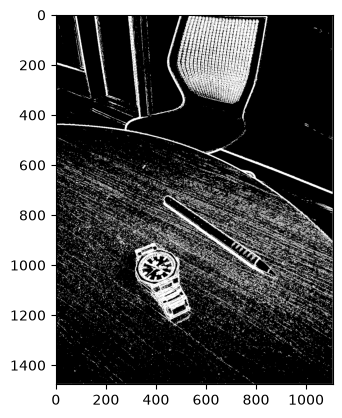

In [43]:
prewitt = np.zeros_like(grey_img, dtype=np.float32)
@ti.kernel
def Prewitt(img: ti.types.ndarray(),
            out: ti.types.ndarray(),
            threshold: ti.types.float32):
    height = img.shape[0] 
    width = img.shape[1]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            dx = ((img[i, j-1] - img[i, j+1]) +
                  (img[i-1, j-1] - img[i-1, j+1]) + 
                  (img[i+1, j-1] - img[i+1, j+1]))
            dy = ((img[i-1, j] - img[i+1, j]) + 
                  (img[i-1, j+1] - img[i+1, j+1]) + 
                  (img[i-1, j-1] - img[i+1, j-1]))
            gradient = ti.sqrt((dx * dx + dy * dy))
            if gradient > threshold:
                out[i, j] = 1
            else:
                out[i, j] = 0

Prewitt(smoothed_img, prewitt, 25)
print(prewitt.shape)
plt.imshow(prewitt, cmap='gray')

### Sobel
We use the same idea but this time the kernel is different
$$
\begin{bmatrix}
    1 & 0 & -1\\
    2 & 0 & -2\\
    1 & 0 & -1
\end{bmatrix}\\
\begin{bmatrix}
    -1 & -2 & -1\\
     0 &  0 &  0\\
     1 &  2 &  1
\end{bmatrix}
$$

Text(0.5, 1.0, 'Sobel')

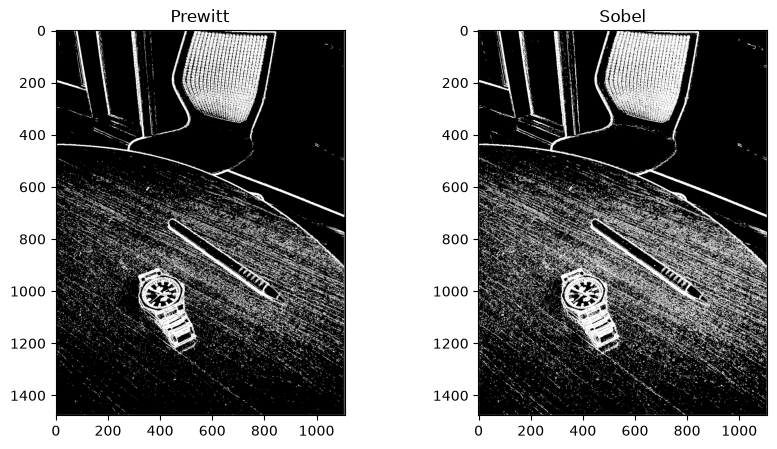

In [44]:
sobel = np.zeros_like(grey_img, dtype=np.float32)
@ti.kernel
def Sobel(img: ti.types.ndarray(),
          out: ti.types.ndarray(),
          threshold: ti.types.float32):
    height = img.shape[0] 
    width = img.shape[1]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            dx = 2 *((img[i, j-1] - img[i, j+1]) +
                  (img[i-1, j-1] - img[i-1, j+1]) + 
                  (img[i+1, j-1] - img[i+1, j+1]))
            dy = 2 * ((img[i-1, j] - img[i+1, j]) + 
                  (img[i-1, j+1] - img[i+1, j+1]) + 
                  (img[i-1, j-1] - img[i+1, j-1]))
            gradient = ti.sqrt((dx * dx + dy * dy))
            if gradient > threshold:
              out[i, j] = 1
            else:
              out[i, j] = 0

Sobel(smoothed_img, sobel, 40)
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(prewitt, cmap='gray')
axes[0].set_title("Prewitt")
axes[1].imshow(sobel, cmap='gray')
axes[1].set_title("Sobel")

With the same threshold, we can see that Sobel has more detail than Prewitt

For now, we still don't know how to choose the threshold for edge detection and $\sigma$ for Gaussian blurring, I just use arbritary value

Text(0.5, 1.0, 'Vertical')

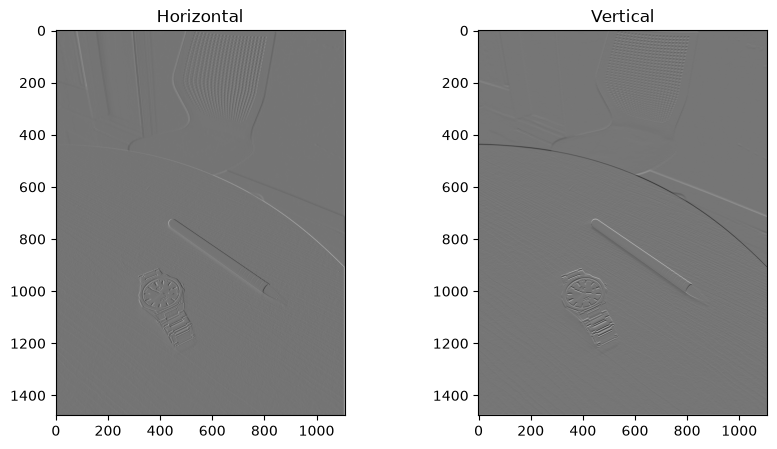

In [45]:
grad_smoothed_horizontal = np.zeros_like(smoothed_img, dtype=np.float32)
grad_smoothed_vertical = np.zeros_like(smoothed_img, dtype=np.float32)
@ti.kernel
def horizontal3x1(img: ti.types.ndarray(),
                  out: ti.types.ndarray(),
                  x_0: ti.types.float32,
                  x_1: ti.types.float32,
                  x_2: ti.types.float32):
    height = img.shape[0]
    width = img.shape[1]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            out[i, j] = (x_0 * img[i, j-1] + 
                         x_1 * img[i  , j] + 
                         x_2 * img[i, j+1])
@ti.kernel
def vertical3x1(img: ti.types.ndarray(),
                out: ti.types.ndarray(),
                y_0: ti.types.float32,
                y_1: ti.types.float32,
                y_2: ti.types.float32):
    height = img.shape[0]
    width = img.shape[1]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            out[i, j] = (y_0 * img[i-1, j] + 
                         y_1 * img[i  , j] + 
                         y_2 * img[i+1, j])

horizontal3x1(smoothed_img, grad_smoothed_horizontal, 1, 0, -1)
vertical3x1(smoothed_img, grad_smoothed_vertical, 1, 0, -1)
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(grad_smoothed_horizontal, cmap='gray')
axes[0].set_title("Horizontal")
axes[1].imshow(grad_smoothed_vertical, cmap='gray')
axes[1].set_title("Vertical")

### Marr and Hildreth
We want to compute 
$$
    \nabla^2 G(x, y, \sigma) \ast I(x, y) = \frac{\partial^2 G(x, y, \sigma)}{\partial x^2} \ast I(x,y) + \frac{\partial G(x, y, \sigma)}{\partial y^2} \ast I(x,y)
$$

The second derivative of Gaussian
$$
\begin{bmatrix} 1 & -2 & 1\end{bmatrix} \ast G(x, y) \approx \frac{\partial^2}{\partial x^2} G(x, y)
$$

So we will have
$$
    \nabla^2 G(x, y, \sigma) \ast I(x, y) = (\begin{bmatrix}1&-2&1\end{bmatrix}\ast G(x,y)\ast I(x,y)) + \\
    (\begin{bmatrix}1\\-2\\1\end{bmatrix}\ast G(x,y)\ast I(x,y))
$$

array([0., 1.], dtype=float32)

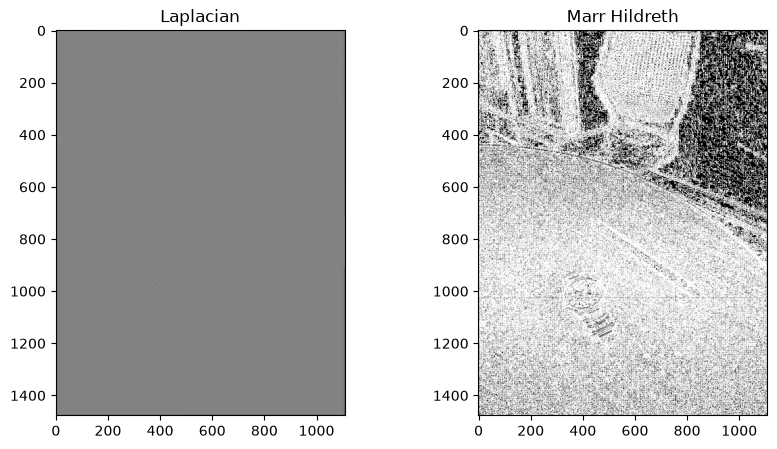

In [56]:
laplacian = np.zeros_like(smoothed_img, dtype=np.float32)
marrhild = np.zeros_like(smoothed_img, dtype=np.float32)
horizontal = np.zeros_like(smoothed_img, dtype=np.float32)
vertical = np.zeros_like(smoothed_img, dtype=np.float32)
@ti.kernel
def Marr_hild(horizontal_smoothed: ti.types.ndarray(),
              vertical_smoothed: ti.types.ndarray(),
              l: ti.types.ndarray(),
              out: ti.types.ndarray(),
              threshold: ti.types.float32):
    height = horizontal_smoothed.shape[0]
    width = horizontal_smoothed.shape[1]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            l[i, j] = horizontal_smoothed[i, j] + vertical_smoothed[i, j]

            # detect zero-crossing
            if l[i, j] > threshold:
                if (
                    l[i-1,j-1] < 0 or
                    l[i-1,j]   < 0 or
                    l[i-1,j+1] < 0 or
                    l[i,j-1]   < 0 or
                    l[i,j+1]   < 0 or
                    l[i+1,j-1] < 0 or
                    l[i+1,j]   < 0 or
                    l[i+1,j+1] < 0
                ):
                    out[i,j] = 1
            elif l[i, j] < threshold:
                if (
                    l[i-1,j-1] > 0 or
                    l[i-1,j]   > 0 or
                    l[i-1,j+1] > 0 or
                    l[i,j-1]   > 0 or
                    l[i,j+1]   > 0 or
                    l[i+1,j-1] > 0 or
                    l[i+1,j]   > 0 or
                    l[i+1,j+1] > 0
                ):
                    out[i,j] = 1
            else: 
                out[i, j] = 0
    
horizontal3x1(smoothed_img, horizontal, 1, -2, 1)
vertical3x1(smoothed_img, vertical, 1, -2, 1)
Marr_hild(horizontal, vertical, laplacian, marrhild, 0)
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(laplacian, cmap='gray')
axes[0].set_title("Laplacian")
axes[1].imshow(marrhild, cmap='gray')
axes[1].set_title("Marr Hildreth")
np.unique(marrhild)